In [1]:
import torch
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [2]:
model=models.segmentation.deeplabv3_resnet101(pretrained=True)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DeepLabV3_ResNet101_Weights.COCO_WITH_VOC_LABELS_V1`. You can also use `weights=DeepLabV3_ResNet101_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


DeepLabV3(
  (backbone): IntermediateLayerGetter(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Se

In [15]:
image_path='/content/TrainSorghumWeed-2-_JPG.rf.1a8828f5d8a36747a72bf8e899e78fd4.jpg'
image_path='car.jpg'
image=Image.open(image_path).convert('RGB')
preprocess=transforms.Compose([
    transforms.Resize((500,500)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])

])
input_tensor=preprocess(image).unsqueeze(0)

In [16]:
with torch.no_grad():
  output=model(input_tensor)['out'][0]

output_predictions=output.argmax(0)

In [17]:
# Map class predictions to colors
def decode_segmentation(mask, num_classes=21):
    # Define color palette for Pascal VOC (21 classes)
    colors = np.array([
        [0, 0, 0], [128, 0, 0], [128, 128, 0],
        [0, 128, 0], [0, 128, 128], [0, 0, 128],
        [128, 0, 128], [128, 128, 128], [64, 0, 0],
        [192, 0, 0], [64, 128, 0], [192, 128, 0],
        [64, 0, 128], [192, 0, 128], [64, 128, 128],
        [192, 128, 128], [0, 64, 0], [128, 64, 0],
        [0, 192, 0], [128, 192, 0], [0, 64, 128]
    ])

    r = np.zeros_like(mask, dtype=np.uint8)
    g = np.zeros_like(mask, dtype=np.uint8)
    b = np.zeros_like(mask, dtype=np.uint8)

    for cls in range(num_classes):
        idx = mask == cls
        r[idx] = colors[cls, 0]
        g[idx] = colors[cls, 1]
        b[idx] = colors[cls, 2]

    return np.stack([r, g, b], axis=2)

# Decode the segmentation map
segmentation_map = decode_segmentation(output_predictions.numpy())


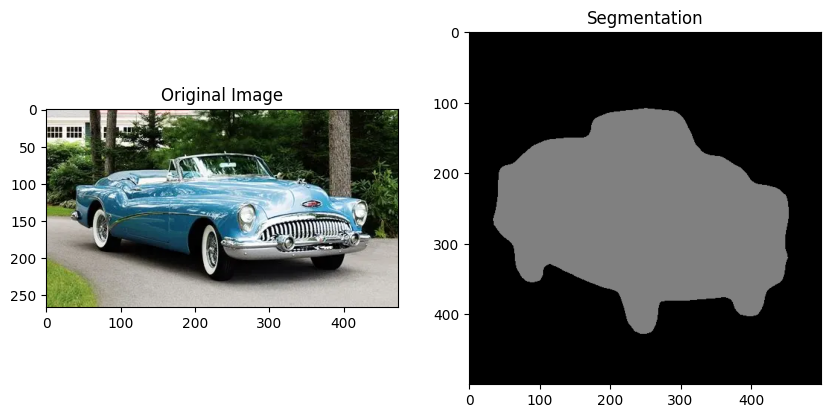

In [18]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Segmentation")

plt.imshow(segmentation_map)
plt.show()

In [19]:
image_path='/content/TrainSorghumWeed-23-_JPG.rf.e175445fde733a6df042e70a94783308.jpg'

image=Image.open(image_path).convert('RGB')
preprocess=transforms.Compose([
    transforms.Resize((500,500)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])

])
input_tensor=preprocess(image).unsqueeze(0)

In [20]:
with torch.no_grad():
  output=model(input_tensor)['out'][0]

output_predictions=output.argmax(0)

In [21]:
segmentation_map = decode_segmentation(output_predictions.numpy())


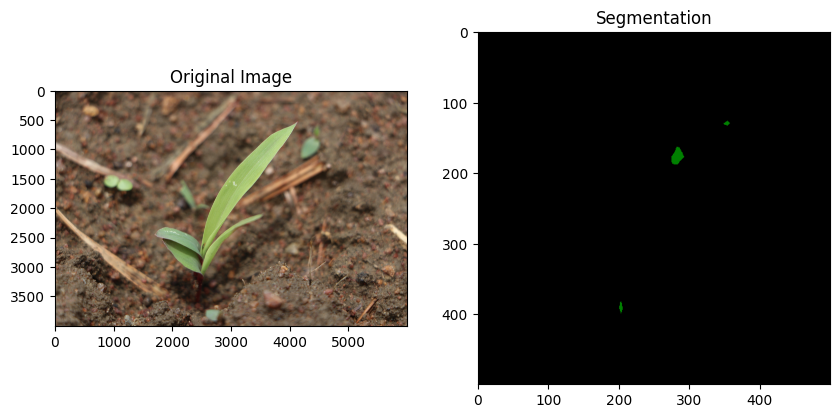

In [22]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(image)

plt.subplot(1,2,2)
plt.title("Segmentation")

plt.imshow(segmentation_map)
plt.show()